# chapter 4. 신경망 학습
이번 장의 주제는 신경망 학습임\
`학습`이란 훈련 데이터로부터 가중치 매개변수의 최적값을 자동으로 획득하는 것을 뜻함\
이번 장에서는 신경망이 학습할 수 있도록 해주는 `지표`인 손실 함수를 소개함\
이 손실 함수의 결괏값을 가장 작게 만드는 가중치 매개변수를 찾는 것이 학습의 목표\
손실 함수의 값을 가급적 작게 만드는 기법으로, 함수의 기울기를 활용하는 경사법을 소개함

## 4.1 데이터에서 학습한다
신경망의 특징은 데이터를 보고 학습할 수 있다는 점임\
데이터에서 학습한다는 것은 가중치 매개변수의 값을 데이터를 보고 자동으로 결정한다는 뜻\
층을 깊게 한 딥러닝 정도 되면 매개변수의 수는 수억개 이상이 되는데 매개변수를 수작업으로 정하기는 불가능함\
이번 장에서는 신경망 학습(데이터로부터 매개변수의 값을 정하는 방법)에 대해서 설명하고 파이썬으로 MNIST 데이터셋의 손글씨 숫자를 학습하는 코드를 구현할 것임

> 퍼셉트론도 직선으로 분리할 수 있는(선형 분리 가능) 문제라면 데이터로부터 자동으로 학습할 수 있음\
선형 분리 가능 문제는 유한 번의 학습을 통해 풀 수 있다는 사실이 퍼셉트론 수렴 정리로 증명되었지만 비선형 분리 문제는 자동으로 학습할 수 없음

### 4.1.1 데이터 주도 학습
데이터에서 답을 찾고 데이터에서 패턴을 발견하고 데이터로 이야기를 만드는 것이 머신러닝\
머신러닝의 중심에는 `데이터`가 존재하며, 이처럼 데이터가 이끄는 접근 방식 덕에 사람 중심 접근에서 벗어날 수 있었음\
머신러닝에서는 사람의 개입을 최소화하고 수집한 데이터로부터 패턴을 찾으려 시도함\
신경망과 딥러닝은 기존 머신러닝에서 사용하던 방법보다 사람의 개입을 더욱 배제할 수 있게 해주는 중요한 특성을 지님

이미지에서 '5'라는 숫자를 인식하는 프로그램을 구현한다고 가정함\
'5'를 인식하는 알고리즘을 밑바닥부터 '설계하는'대신, 주어진 데이터를 잘 활용해서 해결하고 싶어짐\
그런 방법의 하나로, 이미지에서 `특징(feature)`을 추출하고 그 특징의 패턴을 머신러닝 기술로 학습하는 방법이 있음\
여기서 말하는 특징은 입력 데이터(입력 이미지)에서 본질적인 데이터(중요한 데이터)를 정확하게 추출할 수 있도록 설계된 변환기를 가리킴\
이미지의 특징은 보통 벡터로 기술하고, 컴퓨터 비전 분야에서는 SIFT, SURF, HOG 등의 특징을 많이 사용함\
이런 특징을 사용하여 이미지 데이터를 벡터로 변환하고, 변환된 벡터를 가지고 지도 학습 방식의 대표 분류 기법인 SVM, KNN 등으로 학습함\
이와 같이 머신러닝에서는 모아진 데이터로부터 규칙을 찾아내는 역할을 '기계'가 담당함\
다만, 이미지를 벡터로 변환할 때 사용하는 특징은 여전히 '사람'이 설계함\
이 말은 문제에 적합한 특징을 쓰지 않으면(혹은 특징을 설계하지 않으면) 좋은 결과를 얻을 수 없게됨

신경망은 이미지를 '있는 그대로'학습하며, 이미지에 포함된 중요한 특징까지도 '기계'가 스스로 학습할 것임\
예를 들어 '5'를 인식하는 문제든, '개'를 인식하는 문제든 세부사항과 관계없이 신경망은 주어진 데이터를 온전히 학습하고 주어진 문제의 패턴을 발견하려 시도함\
즉, 신경망은 모든 문제를 주어진 데이터 그대로를 입력 데이터로 활용해 'end-to-end'로 학습할 수 있음

> 딥러닝을 종단간 머신러닝(end-to-end machine learning)이라고도 함\
종단간은 '처음부터 끝까지'라는 의미로, 데이터(입력)에서 목표한 결과(출력)를 사람의 개입 없이 얻는다는 뜻을 담고 있음

### 4.1.2 훈련 데이터와 시험 데이터
머신러닝 문제는 데이터를 `훈련 데이터(training data)`와 `시험 데이터(test data)`로 나눠 학습과 실험을 수행하는 것이 일반적\
훈련 데이터만 사용하여 학습하면서 최적의 매개변수를 찾고 시험 데이터를 사용하여 훈련한 모델의 실력을 평가함\
`범용 능력`을 제대로 평가하기 위해 훈련 데이터와 시험 데이터를 분리함
범용 능력은 아직 보지 못한 데이터(훈련 데이터에 포함되지 않는 데이터)로도 문제를 올바르게 풀어내는 능력\
그래서 데이터셋 하나로만 매개변수의 학습과 평가를 수행하면 올바른 평가가 될 수 없음\
수중의 데이터셋은 제대로 맞히더라도 다른 데이터셋에는 엉망인 일도 발생함\
데이터셋에만 지나치게 최적화된 상태를 `과대적합(overfitting)`이라고 함

## 4.2 손실함수
신경망 학습에서는 현재의 상태를 '하나의 지표'로 표현하며, 그 지표를 가장 좋게 만드는 가중치 매개변수의 값을 탐색함\
신경망 학습에서 사용하는 지표는 `손실 함수(loss function)`라고 함\
이 손실 함수는 임의의 함수를 사용할 수도 있지만, 일반적으로는 오차제곱합과 교차 엔트로피 오차를 사용함

### 4.2.1 오차제곱합
가장 많이 쓰이는 손실 함수는 `오차제곱합(sum of squares for error, SSE)`
$$
E = \frac{1}{2}\sum_{k}{(y_k - t_k)^2}
$$

$y_k$는 신경망의 출력(신경망이 추정한 값), $t_k$는 정답 레이블, $k$는 데이터의 차원 수\
예를 들면 손글씨 숫자 인식 예제에서 $y_k$와 $t_k$는 다음과 같은 원소 10개짜리 데이터\
$y$ = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]\
$t$ = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]

이 배열들의 원소는 첫 번째 인덱스부터 순서대로 숫자 '0', '1', '2', ... 일 때의 값\
여기에서 신경망의 출력 $y$는 소프트맥스 함수의 출력임\
소프트맥스 함수의 출력은 확률로 해석할 수 있으므로, 이 예에서는 이미지가 '0'일 확률은 0.1, '1'일 확률은 0.05 라고 해석됨\
정답 레이블인 $t$는 정답을 가리키는 위치의 원소는 1로, 그외에는 0으로 표기함\
여기에서는 숫자 '2'에 해당하는 원소의 값이 1이므로 정답이 '2'임을 알 수 있음\
(이처럼 한 원소만 1로 하고 그 외에는 0으로 나타내는 표기법을 `원-핫 인코딩`)

오차 제곱합을 파이썬으로 구현해보면 다음과 같음

In [2]:
import numpy as np
def sum_squares_error(y,t):
    return 0.5*np.sum((y-t)**2)


여기에서 인수 y와 t는 넘파이 배열임\
이 함수를 실제로 사용해보자

In [5]:
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
print(sum_squares_error(np.array(y),np.array(t)))

0.09750000000000003


In [6]:
y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
print(sum_squares_error(np.array(y),np.array(t)))

0.5975


첫 번째 예시는 정답이 '2'고 신경망의 출력도 '2'에서 가장 높은 경우임\
두 번째 예시는 정답이 '2'지만 신경망의 출력은 '7'에서 가장 높음\
이 실험의 결과로 첫 번째 예시의 손실 함수 출력이 작으며, 정답 레이블과의 오차도 작다는 사실을 알 수 있음\
즉, 오차제곱합 기준으로는 첫 번째 추정 결과가 정답에 더 가까울 것으로 판단할 수 있음

### 4.2.2 교차 엔트로피 오차
또 다른 손실 함수로서 `교차 엔트로피 오차(cross entropy error, CEE)`도 자주 이용함
$$
E = - \sum_{k}{t_k \log{y_k}}
$$

$y_k$는 신경망의 출력, $t_k$는 정답레이블\
$t_k$는 정답에 해당하는 인덱스의 원소만 1이고 나머지는 0(원-핫 인코딩)\
그래서 실질적으로 정답일 때의 추정($t_k$가 1일 때의 $y_k$)의 자연로그를 계산하는 식이 됨\
교차 엔트로피 오차를 구현하면 다음과 같음

In [7]:
def cross_entropy_error(y, t):
    delta = 1e-7
    return -np.sum(t*np.log(y+delta))

y와 t는 넘파이 배열임\
코드 마지막을 보면 np.log를 계산할 때 아주 작은 값인 delta를 더함\
이는 np.log()함수에 0을 입력하면 마이너스 무한대를 뜻하는 -inf가 되어 더이상 계산을 진행할 수 없게 되기 때문임\
따라서 아주 작은 값을 더해서 절대 0이 되지 않도록, 즉 마이너스 무한대가 발생하지 않도록 한 장치

In [8]:
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
print(cross_entropy_error(np.array(y),np.array(t)))

0.510825457099338


In [9]:
y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
print(cross_entropy_error(np.array(y),np.array(t)))

2.302584092994546


첫 번째 예는 정답일 때의 출력이 0.6인 경우로, 이때의 교차 엔트로피 오차는 약 0.51임\
그다음은 정답일 때의 출력이 더 낮은 0.1인 경우로, 이때의 교차 엔트로피 오차는 무려 2.3임\
즉, 결과(오차 값)가 더 작은 첫 번째 추정이 정답일 가능성이 높다고 판단하였고, 이는 앞서 오차제곱합의 판단과 일치함

### 4.2.3 미니배치 학습
머신러닝 문제는 훈련데이터에 대한 손실 함수의 값을 구하고, 그 값을 최대한 줄여주는 매개변수를 찾아냄\
이렇게 하려면 모든 훈련 데이터를 대상으로 손실 함수 값을 구해야 함\
즉, 훈련 데이터가 100개 있으면 그로부터 계산한 100개의 손실 함수 값들의 합을 지표로 삼는 것

지금까지 데이터 하나에 대한 손실 함수만 생각해왔으니, 이제 훈련 데이터 모두에 대한 손실함수의 합을 구하는 방법을 생각해봄\
예를 들어 교차 엔트로피 오차를 구하는 식은 다음과 같음
$$
E = -\frac{1}{N}\sum_{n}{\sum_{k}{t_{nk}\log{y_{nk}}}}
$$

이 때 데이터가 N개 라면 $t_{nk}$는 n번째 데이터의 k번째 값을 의미함($y_{nk}$는 신경망의 출력, $t_{nk}$는 정답 레이블)\
수식이 복잡해 보이지만 데이터 하나에 대한 손실 함수 식을 단순히 N개의 데이터로 확장했을 뿐임\
다만 마지막에 N으로 나누어 정규화하였고, '평균 손실 함수'를 구함\
이렇게 평균을 구해 사용하면 훈련 데이터 개수와 관계없이 언제든 통일된 지표를 얻을 수 있음

하지만 MNIST 데이터셋은 훈련 데이터가 60,000개로 모든 데이터를 대상으로 손실 함수의 합을 구하려면 시간이 오래 걸림\
더 나아가 빅데이터 수준이 되면 그 수는 수백만에서 수천만도 넘는 거대한 값이 되기도 함\
이런 경우 데이터 일부를 추려 전체의 '근사치'로 이용할 수 있으며 신경망 학습에서도 훈련 데이터로부터 일부만 골라 학습을 수행함\
이 일부를 `미니배치(mini-batch)`라고 함\
가령 60,000장의 훈련 데이터 중에서 100장을 무작위로 뽑아 그 100장만을 사용하여 학습하는 것이며 이것을 `미니배치 학습`이라고 함

미니배치 학습을 구현하는, 즉 훈련 데이터에서 지정한 수의 데이터를 무작위로 골라내는 코드를 작성해보자

In [11]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import numpy as np
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

print(x_train.shape)
print(t_train.shape)

(60000, 784)
(60000, 10)


이 훈련 데이터에서 무작위로 10장만 빼내려면 어떻게 할까?\
넘파이의 np.random.choice()함수를 쓰면 해결할 수 있음

In [12]:
train_size = x_train.shape[0]
batch_size = 10
batch_mask = np.random.choice(train_size, batch_size)
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]

np.random.choice()로는 지정한 범위의 수 중에서 무작위로 원하는 개수만 꺼낼 수 있음\
가령 np.random.choice(60000,10)은 0이상 60000미만 수 중에서 무작위로 10개를 골라냄\
이 함수가 출력한 배열을 미니배치로 뽑아낼 데이터의 인덱스로 사용하면 됨

In [13]:
np.random.choice(60000, 10)

array([33040, 36151, 11722, 22503, 13812,     9, 57190, 53928,  2291,
       12274])

이제 무작위로 선택한 이 인덱스를 사용해 미니배치를 뽑아내기만 하면 됨\
손실 함수 또한 이 미니 배치로 계산함

### 4.2.4 배치용 교차 엔트로피 오차 구현하기
미니배치 같은 배치 데이터를 지원하는 교차 엔트로피 오차는 어떻게 구현하는가?\
데이터가 하나인 경우와 데이터가 배치로 묶여 입력될 경우 모두를 처리할 수 있도록 구현해보면 다음과 같음

In [16]:
def cross_entropy_error(y, t):
    if y.ndim==1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
    
    batch_size = y.shape[0]
    return -np.sum(t*np.log(y+1e-7))/batch_size

이 코드에서 y는 신경망의 출력, t는 정답 레이블\
y가 1차원이라면, 즉 데이터 하나당 교차 엔트로피 오차를 구하는 경우는 reshape함수로 데이터의 형상을 바꿔줌\
그리고 배치의 크기로 나눠 정규화하고 이미지 1장당 평균의 교차 엔트로피 오차를 계산함

정답 레이블이 원-핫 인코딩이 아니라 '2'나 '7'등의 숫자 레이블로 주어졌을 때의 교차 엔트로피 오차는 다음과 같이 구현할 수 있음

In [17]:
def cross_entropy_error(y, t):
    if y.ndim==1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
    
    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7))/batch_size

원-핫 인코딩일 때 (첫 번째 함수)\
t가 [0, 0, 1, 0, ...]처럼 원-핫이면 곱셈(t * log(y))으로 정답 위치만 살아남음

숫자 레이블일 때 (두 번째 함수)\
t가 [2, 7, 3, ...]처럼 정수 레이블이면, 원-핫 곱셈 없이 넘파이 팬시 인덱싱으로 정답 위치의 확률값을 직접 뽑아냄

예를 들어 batch_size=3, t=[2, 7, 3]이면

|인덱스	|의미|
|:--|:--|
|y[0, 2]	|0번째 샘플의 정답(2번 클래스) 확률|
|y[1, 7]	|1번째 샘플의 정답(7번 클래스) 확률|
|y[2, 3]	|2번째 샘플의 정답(3번 클래스) 확률|


즉 np.arange(batch_size)가 행 인덱스, t가 열 인덱스 역할을 해서 각 샘플의 정답 클래스에 해당하는 출력값만 정확히 추출\
그래서 원-핫으로 변환할 필요 없이 숫자 레이블 그대로 사용할 수 있는 것임

이 예시에서는 y[np.arange(batch_size), t]는 [y[0, 2], y[1, 7], y[2, 0], y[3, 9], y[4, 4]]인 넘파이 배열 생성

### 4.2.5 왜 손실 함수를 설정하는가?
우리의 궁극적인 목적은 높은 '정확도'를 끌어내는 매개변수 값을 찾는 것인데 왜 '정확도'라는 지표를 놔두고 '순실 함수의 값'이라는 우회적인 방법을 택하는가?

이 의문은 신경망 학습에서의 '미분'의 역할에 주목한다면 해결됨\
신경망 학습에서는 최적의 매개변수(가중치와 편향)를 탐색할 때 손실 함수의 값을 가능한 한 작게 하는 매개변수 값을 찾음\
이 때 매개변수의 미분(정확하게는 기울기)을 계산하고, 그 미분 값을 단서로 매개변수의 값을 서서히 갱신하는 과정을 반복함

가상의 신경망이 있고 그 신경망의 어느 한 가중치 매개변수를 살펴본다고 가정\
이때 그 가중치 매개변수의 손실 함수의 미분이란 '가중치 매개변수의 값을 아주 조금 변화 시켰을 때, 손실 함수가 어떻게 변하나'라는 의미\
만약 이 미분 값이 음수면 그 가중치 매개변수를 양의 방향으로 변화시켜 손실 함수의 값을 줄일 수 있음\
반대로 미분 값이 양수면 가중치 매개변수를 음의 방향으로 변화시켜 손실 함수의 값을 줄일 수 있음\
그러나 미분 값이 0이면 가중치 매개변수를 어느쪽으로 움직여도 손실 함수의 값은 줄어들지 않으며 가중치 매개변수의 갱신은 멈춤\
정확도를 지표로 삼아서는 안되는 이유는 미분 값이 대부분의 장소에서 0이 되어 매개변수를 갱신할 수 없기 때문임

## 4.3 수치미분
### 4.3.1 미분
미분은 한순간의 변화량이며 수식은 다음과 같음
$$
\frac{df(x)}{dx} = \lim_{h \to 0}{\frac{f(x+h)-f(x)}{h}}
$$

위 식을 참고하여 함수를 미분하는 계산을 파이썬으로 구현해보면 다음과 같음

In [18]:
# worse case
def numerical_diff(f,x):
    h = 1e-50
    return (f(x+h)-f(x)) / h

h에 가급적 작은 값을 대입하고 싶었기에 1e-50이라는 작은 값을 이용하였지만 이 방식은 `반올림 오차(rounding error)`문제를 일으킴\
반올림 오차는 작은 값(가령 소수점 8자리 이하)이 생략되어 최종 계산 결과에 오차가 생기게 함\
파이썬에서의 반올림 오차로는 다음과 같은 예시가 있음

In [19]:
np.float32(1e-50)

np.float32(0.0)

이와 같이 1e-50을 float32형(32비트 부동소수점)으로 나타내면 0.0이 되어, 올바로 표현할 수 없음\
너무 작은 값을 이용하면 컴퓨터로 계산하는 데 문제가 됨\
따라서 이 미세한 값을 1e-4로 이용하자($10^{-4}$정도의 값을 사용하면 좋은 결과를 얻는다고 알려져 있음)

두 번째는 함수 f의 차분에 관한 내용임\
앞의 구현에서는 x+h와 x 사이의 함수 f의 차분을 계산하고 있지만 애당초 이 계산에는 오차가 존재함\
'진정한 미분'은 x위치의 함수의 기울기(접선)에 해당하나, 이번 구현에서의 미분은 (x+h)와 x사이의 기울기에 해당함\
수치 미분의 오차를 줄이기 위해 (x+h)와 (x-h)일 때의 함수 $f$의 차분을 계산하는 방법을 쓰기도 함\
이 차분은 x를 중심으로 그 전후의 차분을 계산한다는 의미에서 `중심 차분` 혹은 `중앙 차분`이라 함(원 방식은 `전방 차분`)

> 아주 작은 차분으로 미분하는 것을 `수치 미분`이라고 함\
한편 수식을 전개해 미분하는 것은 `해석적(analytic)`이라는 말을 이용하여 '해석적 해' 혹은 '해석적으로 미분한다' 등으로 표현\
해석적 미분은 오차를 포함하지 않는 '진정한 미분'값을 구해줌\
'해석적 미분'은 수학에서 배운 그 미분이고, '수치 미분'은 이를 '근사치'로 계산하는 방법

두 개선점을 적용해 수치 미분을 다시 구현해보면 다음과 같음

In [20]:
def numerical_diff(f, x):
    h = 1e-4
    return (f(x+h)-f(x-h)) / (2*h)

### 4.3.2 수치 미분의 예
수치 미분을 사용하여 간단한 함수를 미분해보자
$$
y = 0.01x^2 + 0.1x
$$

파이썬으로 구현하면 다음과 같음

In [21]:
def function_1(x):
    return 0.01*x**2 + 0.1*x

이어서 이 함수를 그려보자

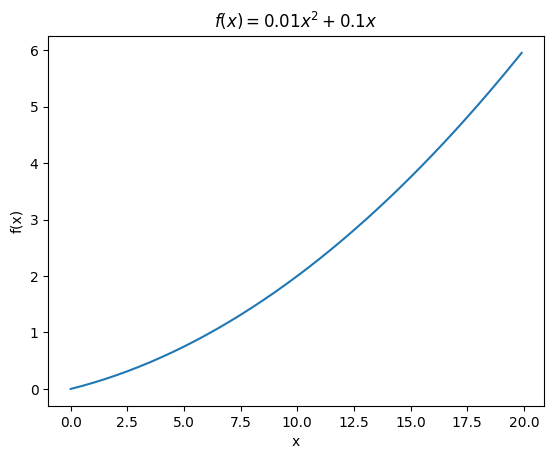

In [25]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)
plt.title('$f(x) = 0.01x^2 + 0.1x$')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.plot(x,y)
plt.show()

In [28]:
# x=5 일때의 수치 미분 값(해석적 미분 값은 0.2)
numerical_diff(function_1, 5)

0.1999999999990898

In [29]:
# x=10 일때의 수치 미분 값(해석적 미분 값은 0.3)
numerical_diff(function_1, 10)

0.2999999999986347

위 예시들의 수치 미분 값과 해석적 해를 비교하면 그 오차가 매우 작음을 알 수 있음

### 4.3.3 편미분
변수가 2개이며 제곱 합을 계산하는 함수가 있다고 가정하자
$$
f(x_0, x_1) = x_{0}^{2} + x_{1}^{2}
$$

이 식은 파이썬으로 다음과 같이 구현 가능함

In [30]:
def function_2(x):
    return x[0]**2 + x[1]**2
    # return np.sum(x**2)

인수 x는 넘파이 배열이라고 가정하면, 이 코드는 넘파이 배열의 각 원소를 제곱하고 그 합을 구할 뿐인 간단한 구현임\
하지만 변수가 2개이기 때문에 '어느 변수에 대한 미분인지'를 구별해야 함\
이와 같이 변수가 여럿인 함수에 대한 미분을 편미분이라고 함

In [31]:
# x0 = 3, x1 = 4일 때 x0에 대한 편미분을 구하라
def function_tmp1(x0):
    return x0*x0 + 4.0**2.0

numerical_diff(function_tmp1, 3.0)

6.00000000000378

In [32]:
# x0 = 3, x1 = 4일 때 x1에 대한 편미분을 구하라
def function_tmp2(x1):
    return 3.0**2.0+ x1*x1

numerical_diff(function_tmp2, 4.0)

7.999999999999119

편미분은 변수가 하나인 미분과 마찬가지로 특정 장소의 기울기를 구함\
단, 여러 변수 중 목표 변수 하나에 초점을 맞추고 다른 변수는 값을 고정함

## 4.4 기울기
앞 절에서는 편미분을 변수별로 따로 계산하였지만 $x_0$와 $x_1$의 편미분을 동시에 계산하려면?\
가령 $x_0=3$, $x_1=4$ 일 때, ($x_0$, $x_1$)양쪽의 편미분을 묶어서 $(\frac{\partial f}{\partial{x_0}},\frac{\partial f}{\partial{x_1}})$ 을 계산한다고 생각해보자\
이 때 $(\frac{\partial f}{\partial{x_0}},\frac{\partial f}{\partial{x_1}})$ 처럼 모든 변수의 편미분을 벡터로 정리한 것을 `기울기(gradient)`라고 함\
기울기는 다음과 같이 구현할 수 있음

In [35]:
def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x) # x와 형상이 같은 배열을 생성
    
    for idx in range(x.size):
        tmp_val = x[idx]
        
        # f(x+h) 계산
        x[idx] = tmp_val + h
        fxh1 = f(x)
        
        # f(x-h) 계산
        x[idx] = tmp_val - h
        fxh2 = f(x)
        
        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val # 값 복원
    
    return grad

In [36]:
numerical_gradient(function_2, np.array([3.0, 4.0]))

array([6., 8.])

In [37]:
numerical_gradient(function_2, np.array([0.0, 2.0]))

array([0., 4.])

In [38]:
numerical_gradient(function_2, np.array([3.0, 0.0]))

array([6., 0.])

이처럼 $(x_0, x_1)$ 의 각 점에서의 기울기를 계산할 수 있음\
이 기울기라는 게 의미하는 건 뭘까?\
기울기는 각 지점에서 낮아지는 방향을 가리킴\
`기울기가 가리키는 쪽은 각 장소에서 함수의 출력 값을 가장 크게 줄이는 방향`

### 4.4.1 경사법(경사 하강법)
머신러닝 문제 대부분은 학습 단계에서 최적의 매개변수를 찾아내며, 신경망 역시 최적의 매개변수(가중치와 편향)를 학습 시에 찾아야함\
최적이란 손실 함수가 최솟값이 될 때의 매개변수 값임\
일반적인 문제의 손실 함수는 매우 복잡하며, 매개변수 공간이 광대하여 어디가 최솟값이 되는 곳인지 짐작할 수 없음\
이런 상황에서 기울기를 잘 이용해 함수의 최솟값(또는 가능한 한 작은 값)을 찾으려는 기법이 경사법\
주의할 점은 각 지점에서 함수의 값을 낮추는 방안을 제시하는 지표가 기울기라는 것임\
하지만 기울기가 가리키는 곳에 정말 함수의 최솟값이 있는지, 즉 그쪽이 정말로 나아갈 방향인지는 보장할 수 없음\
기울어진 방향이 꼭 최솟값을 가리키는 것은 아니나, 그 방향으로 가야 함수의 값을 줄일 수 있음\
그래서 최솟값이 되는 장소를 찾는 문제에서는 기울기 정보를 단서로 나아갈 방향을 정해야 함

경사법은 현 위치에서 기울어진 방향으로 일정 거리만큼 이동한 후 이동한 곳에서도 마찬가지로 기울기를 구하며 나아가기를 반복함\
이렇게 해서 함수의 값을 점차 줄이는 기법이 `경사법(gradient method)`\
경사법을 수식으로 나타내면 다음과 같음
$$
x_0 = x_0 - \eta\frac{\partial f}{\partial x_0} \\[10pt]
x_1 = x_1 - \eta\frac{\partial f}{\partial x_1}
$$

$\eta$(에타, eta) 기호는 갱신하는 양을 나타내며, 이를 신경망 학습에서는 `학습률(learning rate)`이라고 함\
한 번의 학습으로 얼마만큼 학습해야 할지, 즉 매개변수 값을 얼마나 갱신하느냐를 정하는 것이 학습률

위의 식은 1회에 해당하는 갱신이고 이 단계를 반복하는데 즉, 변수의 값을 갱신하는 단계를 여러 번 반복하면서 서서히 함수의 값을 줄임\
위의 예시는 변수가 2개인 경우이지만 변수의 수가 늘어도 각 변수의 편미분 값으로 갱신하게 됨

학습률 값은 0.01이나 0.001 등 미리 특정 값으로 정해두어야 하는데, 일반적으로 이 값이 너무 크거나 작으면 '좋은 장소'를 찾지 못함\
신경망 학습에서는 보통 이 학습률 값을 변경하면서 올바르게 학습하고 있는지를 확인하면서 진행함\
경사 하강법은 다음과 같이 간단하게 구현할 수 있음

In [39]:
def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x
    
    for i in range(step_num):
        grad = numerical_gradient(f,x)
        x -= lr * grad
    
    return x

인수 f는 최적화 하려는 함수, init_x는 초깃값, lr은 learning rate를 의미하는 학습률, step_num은 경사법에 따른 반복 횟수\
함수의 기울기는 numerical_gradient(f,x)로 구하고, 그 기울기에 학습률을 곱한 값으로 갱신하는 처리를 step_num번 반복함

경사법으로 다음 함수의 최솟값을 구하라
$$
f(x_0, x_1) = x_{0}^{2} + x_{1}^{2}
$$

In [40]:
def function_2(x):
    return x[0]**2 + x[1]**2

init_x = np.array([-3.0, 4.0])
gradient_descent(function_2, init_x=init_x, lr=0.1, step_num=100)

array([-6.11110793e-10,  8.14814391e-10])

초깃값을 (-3.0, 4.0)으로 설정한 후 경사법을 사용해 최솟값 탐색을 시작함\
최종 결과는 (-6.11110793e-10, 8.14814391e-10)으로 거의 (0, 0)에 가까운 결과임\
실제로 진정한 최솟값은 (0, 0)이므로 경사법으로 거의 정확한 결과를 구하였음

학습률이 너무 크거나 작으면 좋은 결과를 얻을 수 없다는 것을 실험해봄

In [41]:
init_x = np.array([-3.0, 4.0])
gradient_descent(function_2, init_x=init_x, lr=10.0, step_num=100)

array([-2.58983747e+13, -1.29524862e+12])

In [42]:
init_x = np.array([-3.0, 4.0])
gradient_descent(function_2, init_x=init_x, lr=1e-10, step_num=100)

array([-2.99999994,  3.99999992])

위 실험과 같이 학습률이 너무 크면 큰 값으로 발산해버리고 너무 작으면 갱신되지 않은 채 끝나게 됨

> 학습률 같은 매개변수를 하이퍼파라미터(hyper parameter, 초매개변수)라고 함\
이는 가중치와 편향같은 신경망의 매개변수와는 성질이 다른 매개변수\
신경망의 가중치 매개변수는 훈련 데이터와 학습 알고리즘에 의해서 '자동'으로 획득되는 매개변수인 반면, 학습률 같은 하이퍼파라미터는 사람이 직접 설정해야 하는 매개변수임\
일반적으로 이 하이퍼파라미터들은 여러 후보 값 중에서 시험을 통해 가장 잘 학습하는 값을 찾는 과정을 거쳐야 함

### 4.4.2 신경망에서의 기울기
신경망 학습에서도 기울기를 구해야 함\
여기서 말하는 기울기는 가중치 매개변수에 대한 손실 함수의 기울기임\
예를 들어 형상이 2x3, 가중치가 $W$, 손실 함수가 $L$인 신경망을 생각해보자\
이 경우 경사는 $\frac{\partial L}{\partial W}$로 나타낼 수 있으며 수식은 다음과 같음
$$
W = 
\begin{pmatrix}
w_{11} & w_{12} & w_{13} 

\\[10pt]

w_{21} & w_{22} & w_{23} 
\end{pmatrix}

\\[10pt]

\frac{\partial L}{\partial W} = 
\begin{pmatrix} 
\frac{\partial L}{\partial w_{11}} &
\frac{\partial L}{\partial w_{12}} & 
\frac{\partial L}{\partial w_{13}} 

\\[10pt]

\frac{\partial L}{\partial w_{21}} & 
\frac{\partial L}{\partial w_{22}} & 
\frac{\partial L}{\partial w_{23}}
\end{pmatrix}
$$

$\frac{\partial L}{\partial W}$의 각 원소는 각각의 원소에 관한 편미분임\
예를 들어 1행 1번째 원소인 $\frac{\partial L}{\partial w_{11}}$ 은 $w_{11}$ 을 조금 변경했을 때 손실함수 $L$이 얼마나 변화하느냐를 나타냄

간단한 신경망을 예로 들어 실제로 기울기를 구하는 코드를 구현해보면 다음과 같음

In [5]:
import sys, os
 # 부모 디렉터리의 파일을 가져올 수 있도록 설정
sys.path.append(os.path.join(os.path.dirname(os.getcwd()))) 

import numpy as np
from common.functions import softmax, cross_entropy_error
from common.gradient import numerical_gradient


class simpleNet:
    def __init__(self):
        self.W = np.random.randn(2,3) # 정규분포로 초기화

    def predict(self, x):
        return np.dot(x, self.W)

    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entropy_error(y, t)

        return loss

In [6]:
net = simpleNet()
print(net.W)

[[ 0.73183737 -1.35512802 -0.38236401]
 [ 0.78976548  0.01787889 -0.07656604]]


In [7]:
x = np.array([0.6, 0.9])
p = net.predict(x)
print(p)

[ 1.14989136 -0.79698581 -0.29832785]


In [8]:
np.argmax(p)

np.int64(0)

In [9]:
t = np.array([0, 0, 1])

In [10]:
net.loss(x,t)

np.float64(1.7686394647601524)

In [11]:
def f(W):
    return net.loss(x, t)

dW = numerical_gradient(f, net.W)
print(dW)

[[ 0.43550585  0.06215499 -0.49766083]
 [ 0.65325877  0.09323248 -0.74649125]]


In [12]:
f = lambda w : net.loss(x,t)
dW = numerical_gradient(f, net.W)

## 4.5 학습 알고리즘 구현하기
신경망 학습의 절차는 다음과 같음

|전제|신경망에는 적응 가능한 가중치와 편향이 있고, 이 가중치와 편향을 훈련 데이터에 적응하도록 조정하는 과정이 '학습'<br> 신경망 학습은 다음과 같이 4단계로 수행함|
|:--|:--|
|1단계<br>미니배치|훈련 데이터 중 일부를 무작위로 가져옴<br>이렇게 선별한 데이터를 미니배치라 하며, 그 미니배치의 손실 함수 값을 줄이는 것이 목표|
|2단계<br>기울기 산출|미니배치의 손실 함수 값을 줄이기 위해 각 가중치 매개변수의 기울기를 구함<br>기울기는 손실 함수의 값을 가장 작게 하는 방향을 제시함|
|3단계<br>매개변수 갱신|가중치 매개변수를 기울기 방향으로 아주 조금 갱신함|
|4단계<br>반복|1~3단계를 반복함|

이것이 신경망 학습이 이뤄지는 순서이며, 경사 하강법으로 매개변수를 갱신하는 방법\
이때 데이터를 미니배치로 무작위로 선정하기 때문에 `확률적 경사 하강법(stochastic gradient descent, SGD)`이라고 부름\
'확률적으로 무작위로 골라낸 데이터'에 대해 수행하는 경사 하강법이라는 의미\
대부분의 딥러닝 프레임워크는 확률적 경사 하강법의 영어 머리글자를 딴 `SGD`라는 함수로 이 기능을 구현하고 있음

손글씨 숫자를 대상으로 MNIST 데이터셋을 사용하여 학습을 수행할 것임

### 4.5.1 2층 신경망 클래스 구현하기
처음에는 2층 신경망을 하나의 클래스로 구현하는 일부터 시작하며, 이 클래스의 이름은 TwoLayerNet임

In [13]:
# coding: utf-8
import sys, os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()))) 

from common.functions import *
from common.gradient import numerical_gradient


class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
    
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)
        
        return y
        
    # x : 입력 데이터, t : 정답 레이블
    def loss(self, x, t):
        y = self.predict(x)
        
        return cross_entropy_error(y, t)
    
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)
        
        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy
        
    # x : 입력 데이터, t : 정답 레이블
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)
        
        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])
        
        return grads
        
    def gradient(self, x, t):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        grads = {}
        
        batch_num = x.shape[0]
        
        # forward
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)
        
        # backward
        dy = (y - t) / batch_num
        grads['W2'] = np.dot(z1.T, dy)
        grads['b2'] = np.sum(dy, axis=0)
        
        da1 = np.dot(dy, W2.T)
        dz1 = sigmoid_grad(a1) * da1
        grads['W1'] = np.dot(x.T, dz1)
        grads['b1'] = np.sum(dz1, axis=0)

        return grads

TwoLayerNet 클래스가 사용하는 변수

|변수|설명|
|:--|:--|
|params|신경망의 매개변수를 보관하는 딕셔너리 변수(인스턴스 변수)<br>params['W1']은 1번째 층의 가중치, params['b1']은 1번째 층의 편향<br>params['W2']은 2번째 층의 가중치, params['b2']은 2번째 층의 편향|
|grads|기울기를 보관하는 딕셔너리 변수(numerical_gradient() 메서드의 반환 값)<br>grad['W1']은 1번째 층의 가중치의 기울기, grads['b1']은 1번째 층의 편향의 기울기<br>grad['W2']은 2번째 층의 가중치의 기울기, grads['b2']은 2번째 층의 편향의 기울기|

TwoLayerNet 클래스의 메서드
|메서드|설명|
|:--|:--|
|__init__(self,input_size<br>,hidden_size,output_size)|초기화를 수행함<br>인수는 순서대로 입력층의 뉴런 수, 은닉층의 뉴런 수, 출력층의 뉴런 수|
|predict(self,x)|예측(추론)을 수행함<br>인수x는 이미지 데이터|
|loss(self,x,t)|손실 함수의 값을 구함<br>인수 x는 이미지 데이터, t는 정답 레이블|
|accuracy(self,x,t)|정확도를 구함<br>인수 x는 이미지 데이터, t는 정답 레이블|
|numerical_gradient(<br>self,x,t)|가중치 매개변수의 기울기를 구함<br>인수 x는 이미지 데이터, t는 정답 레이블|
|gradient(self,x,t)|가중치 매개변수의 기울기를 구함<br>인수 x는 이미지 데이터, t는 정답 레이블|

TwoLayerNet 클래스는 딕셔너리인 params와 grads를 인스턴스 변수로 가짐\
params 변수에는 가중치 매개변수가 저장되는데, 예를 들어 1번째 층의 가중치 매개변수는 params['W1']키에 넘파이 배열로 저장됨\
마찬가지로 1번째 층의 편향은 params['b1']키로 접근함

In [14]:
net = TwoLayerNet(input_size = 784, hidden_size= 100, output_size=10)
print(net.params['W1'].shape)
print(net.params['b1'].shape)
print(net.params['W2'].shape)
print(net.params['b2'].shape)

(784, 100)
(100,)
(100, 10)
(10,)


이와 같이 params 변수에는 이 신경망에 필요한 매개변수가 모두 저장됨\
그리고 params 변수에 저장된 가중치 매개변수가 예측 처리(순방향 처리)에서 사용됨\
참고로 예측 처리는 다음과 같이 실행할 수 있음

In [15]:
x = np.random.rand(100, 784)
y = net.predict(x)

grad 변수에는 params 변수에 대응하는 각 매개변수의 기울기가 저장됨\
예를 들어 다음과 같이 numerical_gradient() 메서드를 사용해 기울기를 계산하면 grads 변수에 기울기 정보가 저장됨

In [16]:
x = np.random.rand(100, 784) # 더미 입력 데이터(100장 분량)
t = np.random.rand(100, 10) # 더미 정답 레이블(100장 분량)

grads = net.numerical_gradient(x,t) # 기울기 계산

print(grads['W1'].shape)
print(grads['b1'].shape)
print(grads['W2'].shape)
print(grads['b2'].shape)

(784, 100)
(100,)
(100, 10)
(10,)


TwoLayerNet의 메서드들을 살펴봄\
먼저 __init__(self, input_size, hidden_size, output_size) 메서드는 클래스를 초기화함\
(초기화 메서드는 TwlLayerNet을 생성할 때 불리는 메서드임)\
인수는 순서대로 입력층의 뉴런 수, 은닉층의 뉴런 수, 출력층의 뉴런 수\
예를 들어 손글씨 숫자 인식에서는 크기가 28x28인 입력 이미지가 총 784개이고, 출력은 10개가 됨\
따라서 input_size=784, output_size=10으로 지정하고 은닉층의 개수인 hidden_size는 적당한 값을 설정함

초기화 메서드에서는 가중치 매개변수도 초기화함\
가중치 매개변수의 초깃값을 무엇으로 설정하냐가 신경망 학습의 성공을 좌우하기도 함\
가중치 매개변수 초기화에 대한 자세한 내용은 나중에 살펴볼 것이며 당장은 정규분포를 따르는 난수로, 편향은 0으로 초기화하였음\
predict(self, x)와 accuracy(self, x, t)의 구현은 앞에서 본 신경망의 추론 처리와 거의 같음\
loss(self, x, t)는 손실 함수의 값을 계산하는 메서드며 이 메서드는 predict()의 결과와 정답 레이블을 바탕으로 교차 엔트로피 오차를 구하도록 구현하였음

numerical_gradient(self, x, t) 메서드는 각 매개변수의 기울기를 계산함\
수치 미분 방식으로 각 매개변수의 손실 함수에 대한 기울기를 계산함\
gradient(self, x, t)는 오차역전파법을 사용하여 기울기를 효율적이고 빠르게 계산함

### 4.5.2 미니배치 학습 구현하기
미니배치 학습이란 훈련 데이터 중 일부를 무작위로 꺼내고(미니배치), 그 미니배치에 대해서 경사법으로 매개변수를 갱신함\
TwoLayerNet 클래스와 MNIST 데이터셋을 사용하여 학습을 수행해봄

In [20]:
import numpy as np
from dataset.mnist import load_mnist
import matplotlib.pyplot as plt

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

train_loss_list = []

# 하이퍼 파라미터
iters_num = 10_000 # 반복 횟수
train_size = x_train.shape[0]
batch_size = 100 # 미니배치 크기
learning_rate = 0.1

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

for i in range(iters_num):
    # 미니배치 획득
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    # 기울기 계산
    grad = network.gradient(x_batch, t_batch)
    
    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]
        
    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

train_loss_list


[np.float64(2.291699966493109),
 np.float64(2.2945159927445222),
 np.float64(2.2903077675642707),
 np.float64(2.290900169287379),
 np.float64(2.290023153815535),
 np.float64(2.2878320074768883),
 np.float64(2.2941555427324483),
 np.float64(2.2835639304329947),
 np.float64(2.288145219104424),
 np.float64(2.3002431307031905),
 np.float64(2.292102692341997),
 np.float64(2.300073444350613),
 np.float64(2.2876612507768663),
 np.float64(2.297530045072502),
 np.float64(2.292706053686075),
 np.float64(2.304397894324806),
 np.float64(2.2845297422634063),
 np.float64(2.289409620434831),
 np.float64(2.298332206551952),
 np.float64(2.2985206690274596),
 np.float64(2.301551546767863),
 np.float64(2.2720511738919136),
 np.float64(2.2822139942864825),
 np.float64(2.2741457393771443),
 np.float64(2.2821315902237296),
 np.float64(2.289099234081641),
 np.float64(2.302669223664683),
 np.float64(2.2750181346349088),
 np.float64(2.2881298067824956),
 np.float64(2.294042186769476),
 np.float64(2.31113287625

미니배치 크기를 100으로 해서 매번 60,000개의 훈련 데이터에서 임의로 100개의 데이터(이미지 데이터와 정답 레이블 데이터)를 추려냄\
그 100개의 미니배치를 대상으로 확률적 경사 하강법을 수행해 매개변수를 갱신함\
경사법에 의한 갱신 횟수(반복 횟수)를 10,000번으로 설정하고 갱신할 때마다 훈련 데이터에 대한 손실 함수를 계산하여 배열에 추가함\
학습 횟수가 늘어가면서 손실 함수의 값이 줄어듬\
이는 학습이 잘 되고 있다는 뜻으로, 신경망의 가중치 매개변수가 서서히 데이터에 적응하고 있음을 의미함

### 4.5.3 시험 데이터로 평가하기
학습을 반복함으로써 손실 함수의 값이 서서히 내려가는 것을 확인할 수 있는데, 이때의 손실 함수 값이란 '훈련 데이터의 미니배치에 대한 손실 함수'의 값\
훈련 데이터의 손실 함수 값이 작아지는 것은 신경망이 잘 학습하고 있다는 방증이지만, 이 결과만으로는 다른 데이터셋에도 비슷할지는 불확실함

신경망 학습에서는 훈련 데이터 외의 데이터를 올바르게 인식하는지를 확인해야 함(과대적합을 일으키지 않는지 확인)\
과대적합되었다는 것은 예를 들어 훈련 데이터에 포함된 이미지만 제대로 구분하고, 그렇지 않은 이미지는 식별할 수 없다는 뜻

신경망 학습의 원래 목표는 범용적인 능력을 익히는 것임\
범용 능력을 평가하려면 훈련 데이터에 포함되지 않은 데이터를 사용해 평가해봐야 함\
이를 위해 다음 구현에서는 학습 도중 정기적으로 훈련 데이터와 시험 데이터를 대상으로 정확도를 기록함\
여기에서는 1에포크별로 훈련 데이터와 시험 데이터에 대한 정확도를 기록함

> `에포크(epoch)`는 하나의 단위\
1에포크는 학습에서 훈련 데이터를 모두 소진했을 때의 횟수에 해당함\
가령 훈련 데이터 10,000개를 100개의 미니배치로 학습할 경우, 확률적 경사 하강법을 100회 반복하면 모든 훈련 데이터를 '소진'한 것이 됨\
이 경우 100회가 1에포크가 됨

In [21]:
import numpy as np
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

# 하이퍼 파라미터
iters_num = 10_000 # 반복 횟수
train_size = x_train.shape[0]
batch_size = 100 # 미니배치 크기
learning_rate = 0.1

train_loss_list = []
train_acc_list = []
test_acc_list = []

# 1에포크당 반복 수
iter_per_epoch = max(train_size/batch_size,1)

for i in range(iters_num):
    # 미니배치 획득
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    # 기울기 계산
    grad = network.gradient(x_batch, t_batch)
    
    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]
        
    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)
    
    # 1에포크당 정확도 계산
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test cc | " + str(train_acc) + ", " + str(test_acc))

train acc, test cc | 0.0993, 0.1032
train acc, test cc | 0.78875, 0.7931
train acc, test cc | 0.8731833333333333, 0.877
train acc, test cc | 0.89605, 0.8973
train acc, test cc | 0.9054666666666666, 0.9078
train acc, test cc | 0.9123, 0.9134
train acc, test cc | 0.9175833333333333, 0.9208
train acc, test cc | 0.9216333333333333, 0.9222
train acc, test cc | 0.9246166666666666, 0.9258
train acc, test cc | 0.9289833333333334, 0.9301
train acc, test cc | 0.9317, 0.9317
train acc, test cc | 0.9348666666666666, 0.9352
train acc, test cc | 0.93735, 0.9371
train acc, test cc | 0.9391833333333334, 0.9397
train acc, test cc | 0.94155, 0.9405
train acc, test cc | 0.94395, 0.9419
train acc, test cc | 0.9449666666666666, 0.944


이 예시에서는 1에포크마다 모든 훈련 데이터와 시험 데이터에 대한 정확도를 계산하고, 그 결과를 기록함\
정확도를 1에포크마다 계산하는 이유는 for문 안에서 매번 계산하기에는 시간이 오래 걸리고, 또 그렇게까지 자주 기록할 필요는 없기 때문\
더 큰 관점에서 그 추이를 알 수 있으면 충분함